In [2]:
from src.layers.transformer.ATAT import LightCurveTransformer
from src.utils.data.AlerceDictionaries import ELASTICC_TAXONOMY,ZTF_TAXONOMY
import pandas as pd

In [3]:
colors = [
    '#ffacfa',# agn
    '#D747CF', #qso 1
    "#189a95", # EA 2

    "#bb3e00", #yso 3
    '#70df00',  # snia 4
    "#FE0912", # cvnova 5
    
    '#009cff',# 6 rrlc  tt
    "#0004ffff",  # 7 rscvn
    "#cd0066",#'#96034A', #blacar 8
    
    '#2F8B04', # snii 9 
    '#7a71f8', # ebew 10
    "#3b3ee7ff", #lpv 11
    
    "#41708f", # cep 12
    '#00e3ff', # rrlab 13
    '#1FA9FF', # periodic other 14
     '#00e3ff', #dsct 15
    "#458a00", # snibc 16
    "#1E5A2E", # slsn 17
    "#ff8000", # tde 18

    '#FFC71F', # sniib 19
    '#FFEC1F', # sniin 20
    "#FFFFFF", # microlensing 21
    ]

colors_hier = [
    #,'#554FCF
    #'#FBAC23', #agn 0
    '#fd31ee',# agn
    '#fd31ee', #qso 1
    '#00e3ff', # EA 2

    '#fd31ee', #yso 3
    '#1bda00',  # snia 4
    '#fd31ee', # cvnova 5
    '#00e3ff',# 6 rrlc  tt
    '#00e3ff',  # 7 rscvn
    '#fd31ee',#'#96034A', #blacar 8
    '#1bda00', # snii 9 
    '#00e3ff', # ebew 10
    '#00e3ff', #lpv 11
    
    '#00e3ff', # cep 12
    '#00e3ff', # rrlab 13
    '#00e3ff', # periodic other 14
    '#60fff3 ', #dsct 15
    '#1bda00', # snibc 16
    '#1bda00', # slsn 17
    '#1bda00', # tde 18
    '#1bda00', # sniib 19
    '#1bda00', # sniin 20
    '#1bda00', # microlensing 21
    ]

In [4]:
PATH = '/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/200/LC/multiview_v1/'
FP_DATASET = "/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/data/datasets/ZTF_ff/final/LC_MD_FEAT_240627_windows_200_12/dataset.h5"
FP_DATASET ='/home/mdelafuente/ZTF_SSL_Dataset/data/H5_files/BY_PARTITION/200_FF.h5'
DEVICE = 'cuda:0'
TAXONOMY = ZTF_TAXONOMY

In [5]:
from src.exploringtools.ExplorePretraining import ExplorePretraining
from src.exploringtools.InitDataloader import InitDataLoader
test = ExplorePretraining(path_to_config_yaml=PATH,
                    model= LightCurveTransformer, 
                    arg_key='lc')
od = test.create_ordered_dict(remove_if_in_key_list=['projection', 'model_tab', 'classifier'],rename_keys = ('model.',''), checkpoint_name='pretrain_ckpt')
test.load_backbone_weights(od)
dl = InitDataLoader(update_dataset_path=FP_DATASET,update_batch_size=16,datamodule_args=test.args.datamodule)

Found checkpoint 1484.ckpt
Loaded backbone weights
not using sampler


/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/src/exploringtools/InitBackbone.py:42: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serializati

In [6]:
X_val, y_val =test.predict(dl.validation_dataset, DEVICE)

device set to cuda:0


100%|██████████| 382/382 [00:03<00:00, 109.42it/s]


In [7]:
target = y_val
from sklearn.discriminant_analysis import StandardScaler
import umap
import umap.plot
#from bokeh.resources import INLINE
#import bokeh.io
scaler = StandardScaler()
#bokeh.io.output_notebook(INLINE)
umap_args = {'min_dist':0.99}
umap_obj = umap.UMAP(**umap_args)
mapper = umap_obj.fit(scaler.fit_transform(X_val))
hover_data = pd.DataFrame({'index':range(len(X_val)),
                            'label':y_val, 
                            })

hover_data['class'] = hover_data.label.map({value:key for key,value in TAXONOMY().items()})

/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/numba/np/ufunc/dufunc.py:343: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)
/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/numba/np/ufunc/dufunc.py:343: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)
/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/numba/np/ufunc/dufunc.py:343: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the s

In [8]:
umap.plot.output_notebook()
p = umap.plot.interactive(mapper, 
    labels=target,
    hover_data=hover_data,
    point_size=5,
    tools=["pan","wheel_zoom",
    "box_zoom","save",
    "reset","box_select"],
    width=1920,
    height=1080,
    #theme = 'fire',
    #color_key = colors_hier,
    color_key = colors,
    background = 'black', #midnightblue',
    alpha = 0.9)
umap.plot.show(p)

Loading BokehJS ...

In [8]:
#dl.set_sampler(True)
X_train, y_train =test.predict(dl.train_dataset, DEVICE)

device set to cuda:0


100%|██████████| 1525/1525 [00:21<00:00, 70.08it/s]


In [ ]:
class_sampler_count  = [1783,1804,1785,1526,1566,1008,1855,1440,872,891,1858,1860,1814,1876,763,973,278,121,56,70,172,17]

weights_dict = {float(i): 1/class_sampler_count[i] for i in range(len(class_sampler_count))}

In [9]:
import numpy as np
#print(1/np.array(class_sampler_count))
new = 1/np.array(class_sampler_count)**2
print(new/np.linalg.norm(new))

[9.03449410e-05 8.82538090e-05 9.01426008e-05 1.23338158e-04
 1.17117828e-04 2.82673737e-04 8.34677482e-05 1.38510131e-04
 3.77723109e-04 3.61785467e-04 8.31984252e-05 8.30196000e-05
 8.72834612e-05 8.16095263e-05 4.93352632e-04 3.03375737e-04
 3.71635278e-03 1.96171442e-02 9.15862909e-02 5.86152262e-02
 9.70844403e-03 9.93822174e-01]


In [10]:
from sklearn.metrics import classification_report
train_preds, val_preds = test.compute_logistic_regressor(X_train, y_train, X_val, y_val, ZTF_TAXONOMY,weights = weights_dict)

/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


In [11]:
0.1729,0.1625,0.1424,0.1656,0.1786,0.1874,0.1968,0.2038,0.2057,0.2163,0.2269,0.2307,0.2333,0.2329,0.2364,0.2400,0.2382,0.2390,0.2433,0.2426,0.2461,0.2453,0.2465,0.2497,0.2509

(0.1729,
 0.1625,
 0.1424,
 0.1656,
 0.1786,
 0.1874,
 0.1968,
 0.2038,
 0.2057,
 0.2163,
 0.2269,
 0.2307,
 0.2333,
 0.2329,
 0.2364,
 0.24,
 0.2382,
 0.239,
 0.2433,
 0.2426,
 0.2461,
 0.2453,
 0.2465,
 0.2497,
 0.2509)

                precision    recall  f1-score   support

           AGN     0.3441    0.0722    0.1194       443
           QSO     0.5222    0.5660    0.5433       477
            EA     0.4437    0.3899    0.4151       495
           YSO     0.3915    0.2180    0.2801       422
          SNIa     0.5725    0.4107    0.4783       375
       CV/Nova     0.3891    0.3948    0.3919       271
          RRLc     0.4382    0.3429    0.3847       455
         RSCVn     0.2159    0.0562    0.0892       338
        Blazar     0.1981    0.1000    0.1329       210
          SNII     0.3617    0.0825    0.1344       206
         EB/EW     0.5000    0.4768    0.4881       453
           LPV     0.4121    0.6397    0.5013       458
           CEP     0.2707    0.1381    0.1829       449
         RRLab     0.3954    0.5756    0.4688       450
Periodic-Other     0.1622    0.3636    0.2243       198
          DSCT     0.1795    0.3182    0.2295       242
         SNIbc     0.1268    0.1364    0.1314  

<Axes: title={'center': 'logit reg: validation | macro f1: 0.2478'}, xlabel='Predicted label', ylabel='True label'>

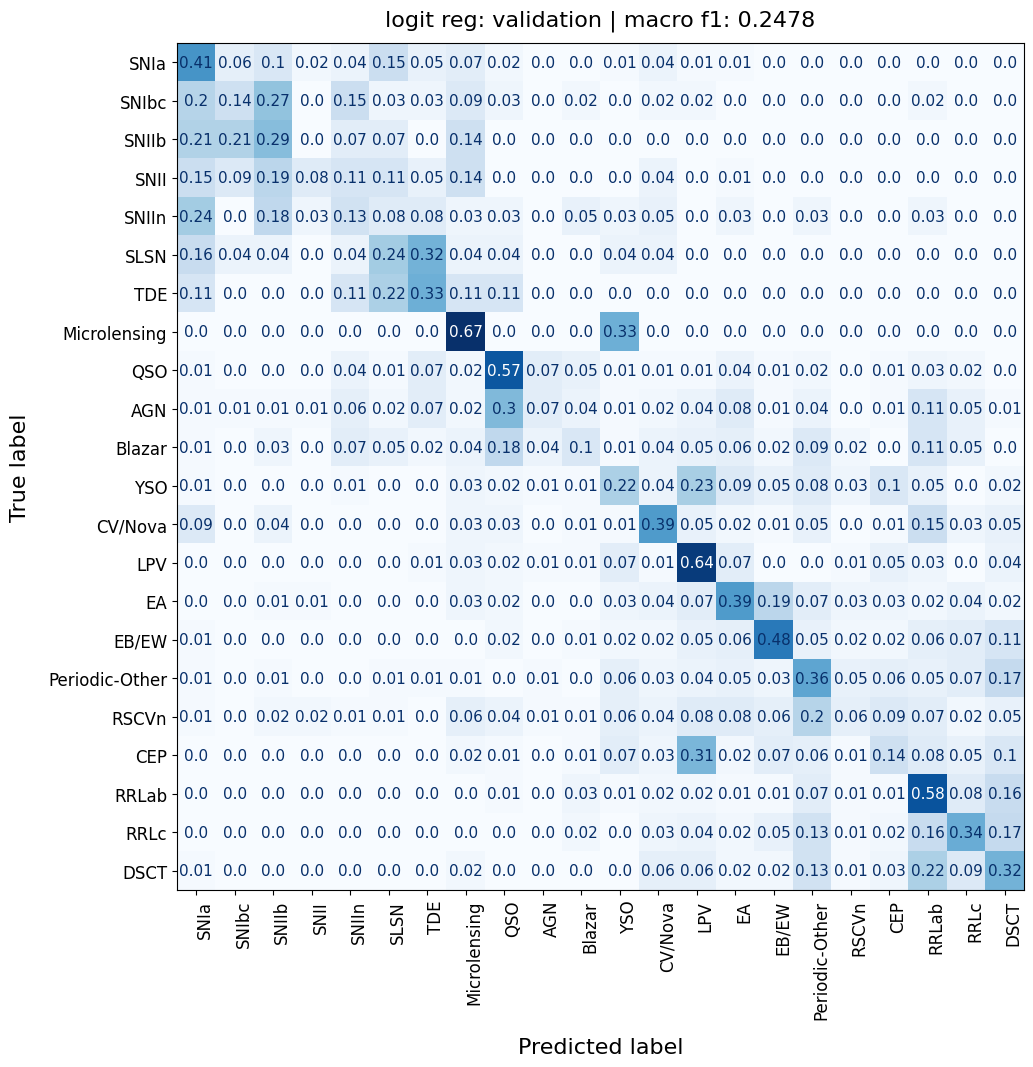

In [12]:
print(classification_report(y_val,val_preds, target_names=list(TAXONOMY().keys()),digits = 4))
test.get_confusion_matrix(val_preds, y_val, ZTF_TAXONOMY, dataset_type = 'validation')

/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metr

                precision    recall  f1-score   support

           AGN     0.3384    0.4018    0.3674       443
           QSO     0.5487    0.5786    0.5633       477
            EA     0.6222    0.6687    0.6446       495
           YSO     0.4043    0.4005    0.4024       422
          SNIa     0.5989    0.8400    0.6992       375
       CV/Nova     0.5816    0.4207    0.4882       271
          RRLc     0.4577    0.6066    0.5217       455
         RSCVn     0.3446    0.3314    0.3379       338
        Blazar     0.3400    0.1619    0.2194       210
          SNII     0.5029    0.4223    0.4591       206
         EB/EW     0.5353    0.5695    0.5519       453
           LPV     0.6660    0.7271    0.6952       458
           CEP     0.4809    0.4209    0.4489       449
         RRLab     0.5739    0.6644    0.6159       450
Periodic-Other     0.2952    0.1566    0.2046       198
          DSCT     0.3007    0.1901    0.2329       242
         SNIbc     0.2308    0.0909    0.1304  

/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


<Axes: title={'center': 'logit reg: validation | macro f1: 0.3535'}, xlabel='Predicted label', ylabel='True label'>

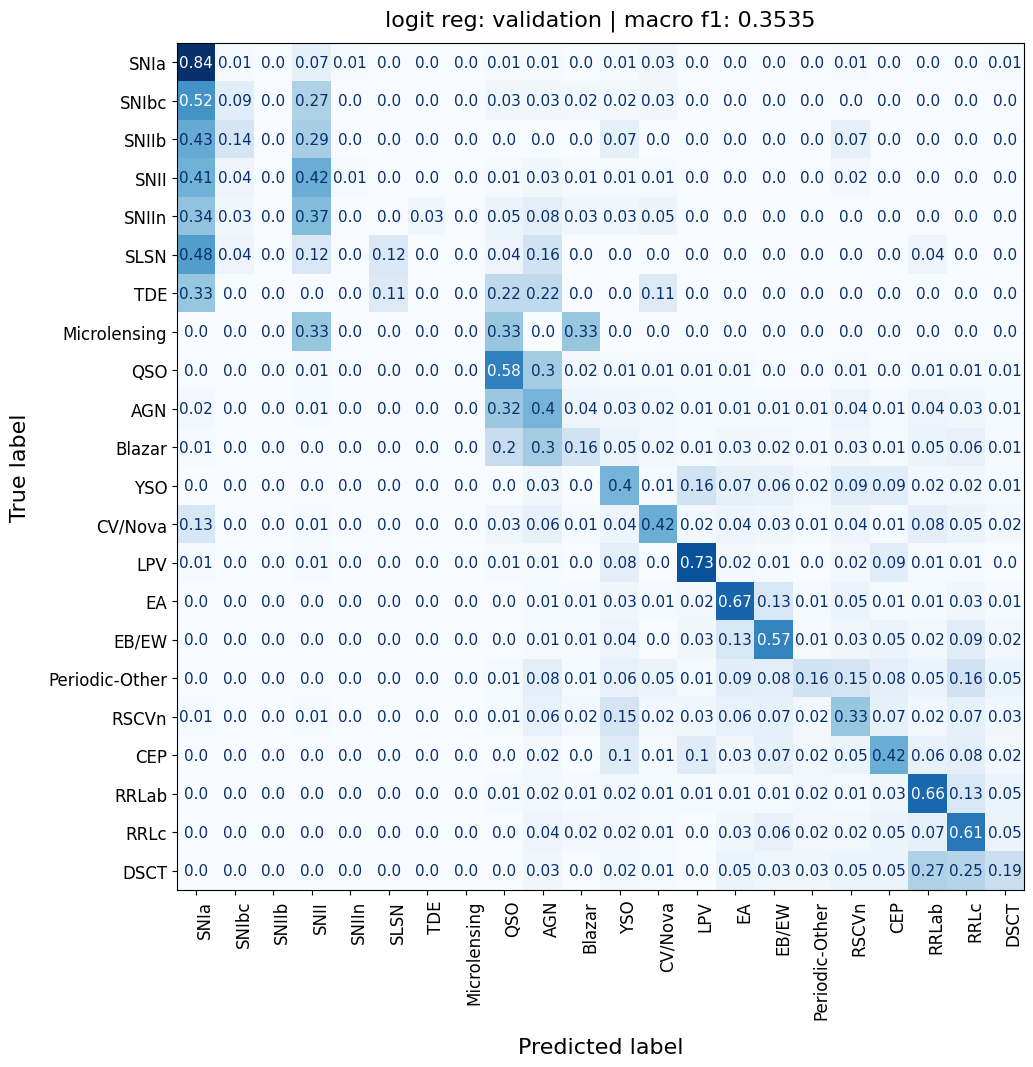

In [13]:
train_preds, val_preds = test.compute_knn(X_train, y_train, X_val, y_val, ZTF_TAXONOMY)
print(classification_report(y_val,val_preds, target_names=list(TAXONOMY().keys()),digits = 4))
test.get_confusion_matrix(val_preds, y_val, ZTF_TAXONOMY, dataset_type = 'validation')

In [14]:
#print(classification_report(y_train,train_preds, target_names=list(TAXONOMY().keys()),digits = 4))

In [15]:
asdf

NameError: name 'asdf' is not defined

In [ ]:
from sklearn.discriminant_analysis import StandardScaler
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

model1 = Pipeline([
            ('scaler', StandardScaler()),  # z = (x - mean) / std
            ('model', LogisticRegression(random_state=0, max_iter = 1000, multi_class = 'ovr', class_weight=weights_dict))
        ])
model2 =  Pipeline([
            ('scaler', StandardScaler()),  # z = (x - mean) / std
             ('model', KNeighborsClassifier(n_neighbors=3,weights='distance'))
        ])
model3 = RandomForestClassifier()

ensemble = VotingClassifier(estimators=[
    ('lr', model1), 
    ('rf', model3),
     ('model', model2)
], voting='soft')
ensemble.fit(X_train, y_train)
y_pred = ensemble.predict(X_val)

print(classification_report(y_val,y_pred, target_names=list(TAXONOMY().keys()),digits = 4))

/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


KeyboardInterrupt: 